# 06 — Comparación de clustering

Este notebook resume M7. Compara MiniBatchKMeans, HDBSCAN y CURE sobre las mismas 20,000 filas de ajuste.

La pregunta es: **¿qué método produce grupos utilizables, estables y asignables a reclamos futuros?**

## 1. Cargar los resultados

In [1]:
import json
from pathlib import Path

import pandas as pd
import yaml
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

report_path = PROJECT_ROOT / 'reports/modeling/clustering_results.json'
report = json.loads(report_path.read_text(encoding='utf-8'))
print(f'Reporte: {report_path.relative_to(PROJECT_ROOT)}')
print(f"Método recomendado: {report['decision']['recommended_algorithm']}")
print(f"Tiempo total: {report['resources']['elapsed_seconds'] / 60:.2f} minutos")

Reporte: reports/modeling/clustering_results.json
Método recomendado: kmeans
Tiempo total: 26.38 minutos


## 2. Resultado principal

- **Silhouette:** mide separación; un valor mayor es mejor, pero puede ser engañoso si el método descarta muchos casos o crea un grupo gigante.
- **ARI:** mide si aparecen grupos parecidos al repetir el análisis sobre muestras distintas.
- **Cobertura futura:** porcentaje de calibración que puede asignarse dentro de las distancias conocidas.

In [2]:
summary_rows = []
for algorithm, values in report['selected'].items():
    summary_rows.append({
        'Método': algorithm,
        'Configuración': values['id'],
        'Grupos': int(values['clusters']),
        'Silhouette': values['silhouette_mean'],
        'ARI': values['stability_ari'],
        'Ruido': values['noise_fraction'],
        'Grupo más grande': values['largest_cluster_fraction'],
        'Cobertura futura': values['future_coverage'],
        'Aceptado': values['accepted'],
    })

summary = pd.DataFrame(summary_rows)
display(summary.round(4))

,Método,Configuración,Grupos,Silhouette,ARI,Ruido,Grupo más grande,Cobertura futura,Aceptado
0,kmeans,kmeans_k40,40,0.1376,0.6260,0.0000,0.1388,0.9899,True
1,hdbscan,hdbscan_mcs500_ms30,2,0.5455,1.0000,0.4891,0.4656,0.6263,False
2,cure,cure_k20_r5_c0.5,20,0.4093,0.4307,0.0000,0.9921,0.9576,False


## 3. Silhouette no es suficiente

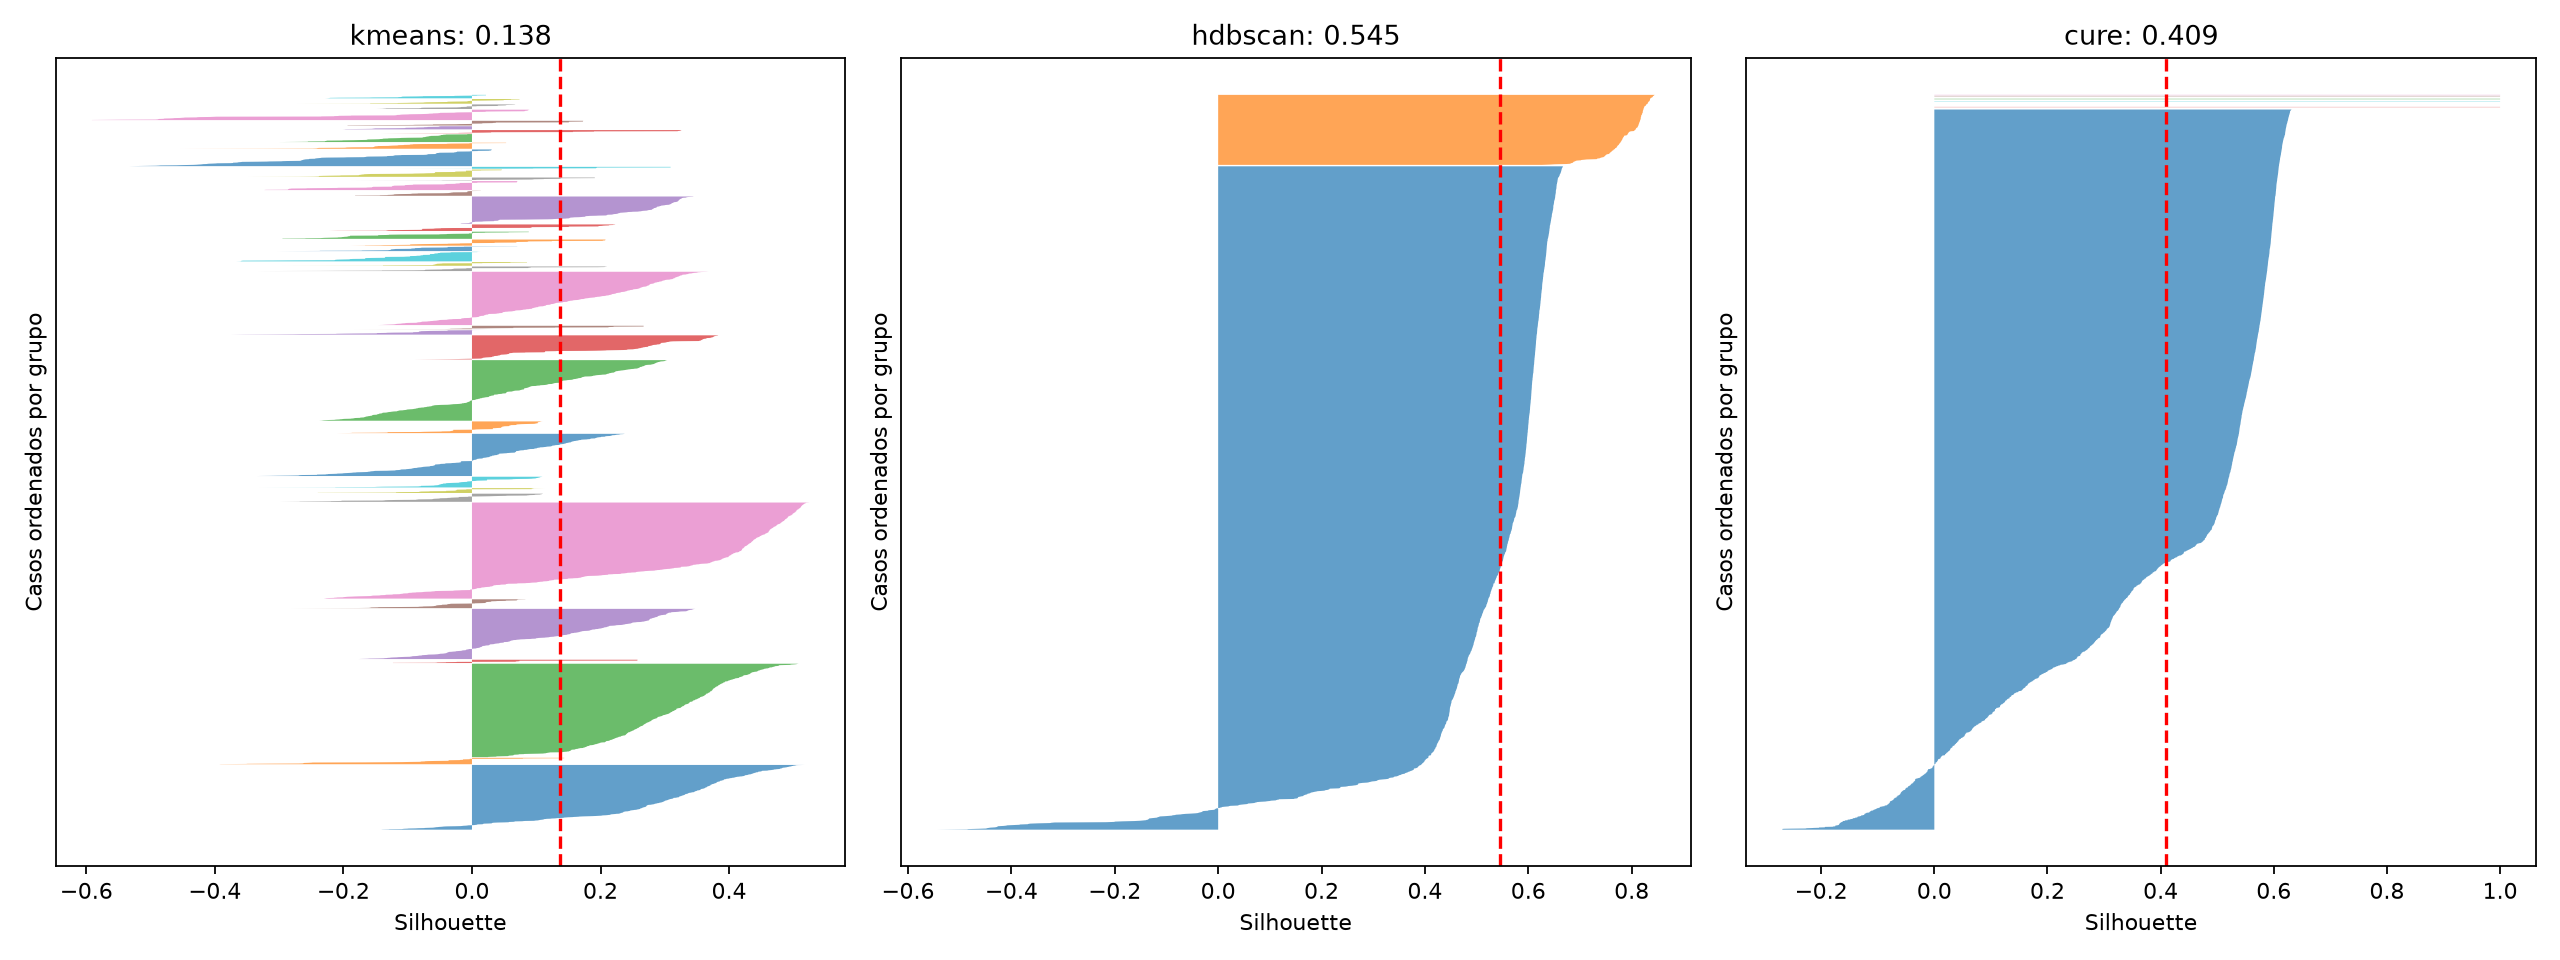

In [3]:
display(Image(filename=str(PROJECT_ROOT / 'reports/modeling/clustering_silhouette.png')))

HDBSCAN tiene el silhouette más alto, pero solo conserva dos grupos y deja 48.91% como ruido. CURE también obtiene un valor alto, pero concentra 99.21% de los reclamos en un solo grupo. Por eso ambos se rechazan.

## 4. Tamaños de los grupos

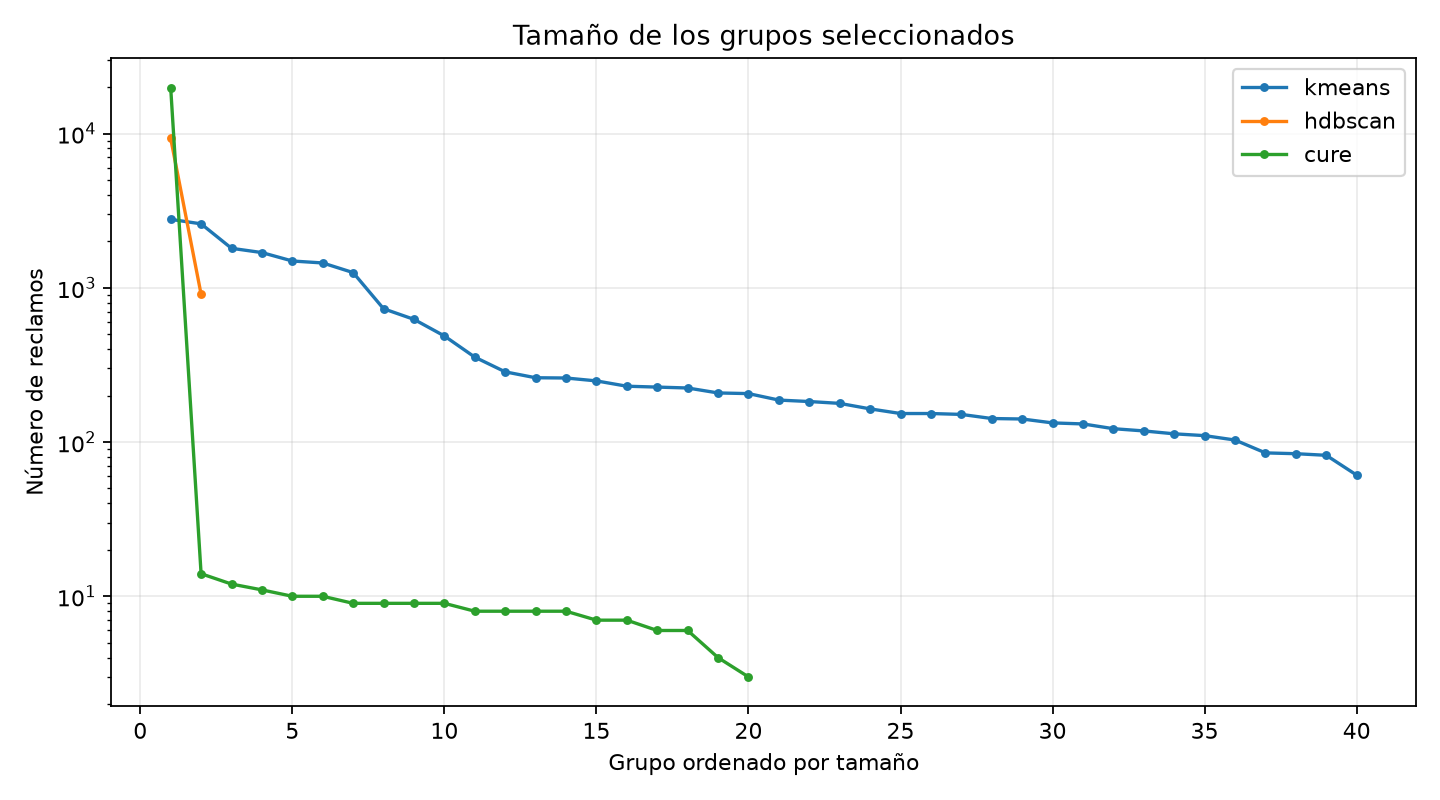

In [4]:
display(Image(filename=str(PROJECT_ROOT / 'reports/modeling/clustering_sizes.png')))

k-means distribuye los casos entre 40 grupos. El mayor contiene 13.89% de la muestra. CURE muestra claramente el problema del grupo gigante.

## 5. Vista UMAP 2D

El clustering se ajustó sobre UMAP de 15 dimensiones. Esta proyección 2D se usa únicamente para inspección.

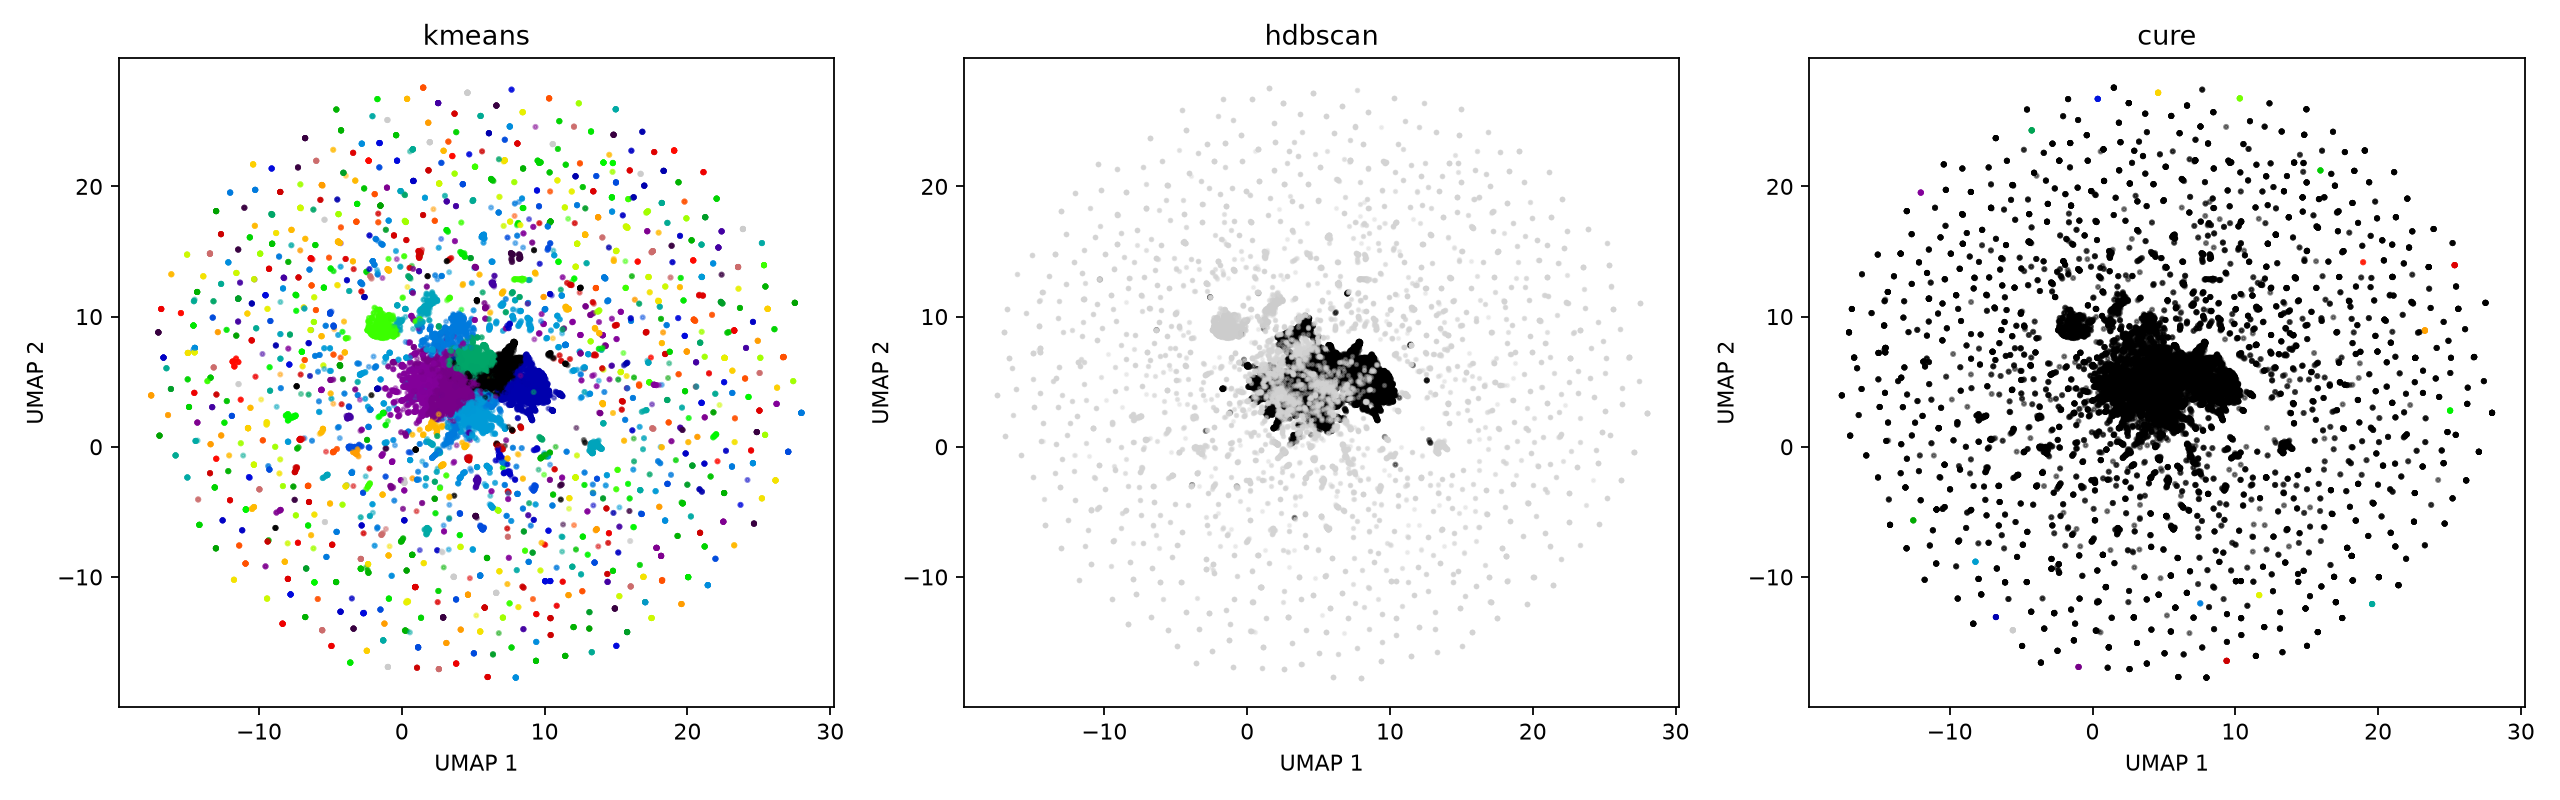

In [5]:
display(Image(filename=str(PROJECT_ROOT / 'reports/modeling/clustering_umap_2d.png')))

## 6. Qué significa elegir k-means

MiniBatchKMeans con `k=40` fue el único que pasó todos los criterios:

- ningún caso quedó sin grupo;
- estabilidad ARI de 0.6260;
- 98.99% de cobertura futura;
- 71.01% de los vecinos BGE comparten grupo;
- ningún grupo está dominado en más de 50% por una plantilla.

La separación sigue siendo moderada: silhouette 0.1376 y 28.96% de valores negativos. Por eso los 40 grupos son una **partición de trabajo**, no categorías naturales confirmadas.

## 7. Artefacto reproducible

In [6]:
dvc_path = PROJECT_ROOT / 'artifacts/models/clustering_comparison.dvc'
dvc_output = yaml.safe_load(dvc_path.read_text(encoding='utf-8'))['outs'][0]
artifact = pd.Series({
    'Ruta': 'artifacts/models/clustering_comparison',
    'Hash DVC': dvc_output['md5'],
    'Tamaño en bytes': dvc_output['size'],
    'Archivos': dvc_output['nfiles'],
})
display(artifact.to_frame('Valor'))

,Valor
Ruta,artifacts/models/clustering_comparison
Hash DVC,425408aa84d0e2a44b8c5becd467e724.dir
Tamaño en bytes,345751521
Archivos,28


## 8. Decisión

M7 queda aprobado con MiniBatchKMeans y `k=40`. En M8 se generarán los embeddings faltantes y se ajustará el modelo con todos los reclamos elegibles del periodo de ajuste antes de construir conteos semanales.

El run está disponible en [MLflow](https://dagshub.com/WinzCode/capstone-claims-triage.mlflow/#/experiments/0/runs/6a54e373da2641f8a3ae0839d0faaad1).